### Import Libraries

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken
import matplotlib.pyplot as plt
import re

### Load and Inspect Raw Text Data

In [4]:
with open("/content/a-man-thinketh.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 24748
The aphorism, "As a man thinketh in his heart so is he," not only embraces the whole of a man's bei


In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

In [6]:
print(len(preprocessed))

4781


### Build Sliding Window Dataset

In [ ]:
class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize entire text
        token_ids = tokenizer.encode(txt)
        print("Total tokens:", len(token_ids))

        # Create input-target pairs using sliding window
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [ ]:
def create_dataloader(txt, tokenizer, batch_size=4, max_length=256, stride=128, shuffle=True):
    dataset = GPTDataset(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader

### Multi-Head Self Attention with Causal Mask

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [ ]:
# Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# GELU Activation Function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

# Feed Forward Network
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), ## Expansion
            GELU(), ## Activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), ## Contraction
        )

    def forward(self, x):
        return self.layers(x)

### Transformer Block (Attention + FFN + Residual Connections)

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # 2*4*768
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x
        # 2*4*768

### Full GPT Model Architecture

In [11]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### Model Configuration and Initialization

In [12]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 6,
    "drop_rate": 0.2,
    "qkv_bias": False
}

# Your existing GPTModel class here
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)

Using device: cuda


### Model Parameter Count

In [13]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 30,531,584


In [14]:
total_params_model = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_model:,}")

Number of trainable parameters considering weight tying: 17,665,792


### Batch and Dataloader Loss Functions

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss   = nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss


def calc_loss_dataloader(dataloader, model, device, num_batches=None):
    total_loss = 0.0
    if num_batches is None:
        num_batches = len(dataloader)
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches


### Text Generation with Temperature and Top-K Sampling

In [ ]:
def generate_text(model, idx, max_new_tokens, context_size,
                  temperature=1.0, top_k=None):
    """
    Autoregressive text generation with:
      - temperature  : >1 = more random, <1 = more focused
      - top_k        : only sample from top-k most likely tokens
    """
    model.eval()
    for _ in range(max_new_tokens):

        # crop context to model's max context size
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)          # (B, T, vocab_size)

        logits = logits[:, -1, :]             # last token → (B, vocab_size)

        # temperature scaling
        logits = logits / temperature

        # top-k filtering
        if top_k is not None:
            top_values, _ = torch.topk(logits, top_k)
            # get the smallest value in top-k
            min_val = top_values[:, -1].unsqueeze(-1)
            # mask everything below that value
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        probs = torch.softmax(logits, dim=-1)  # (B, vocab_size)

        # sample instead of argmax
        idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)

        idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)

    return idx

In [ ]:
def generate_and_print(model, tokenizer, start_context, device,
                       max_new_tokens=50, temperature=0.8, top_k=50):
    model.eval()
    encoded        = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)

    with torch.no_grad():
        out = generate_text(
            model=model,
            idx=encoded_tensor,
            max_new_tokens=max_new_tokens,
            context_size=GPT_CONFIG_124M["context_length"],
            temperature=temperature,
            top_k=top_k
        )

    decoded = tokenizer.decode(out.squeeze(0).tolist())
    print(decoded)
    model.train()

### Training Loop with Evaluation and Sampling

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, device,
                num_epochs, eval_freq, eval_iter,
                tokenizer, start_context,
                temperature=0.8, top_k=50):

    train_losses, val_losses = [], []
    global_step = 0

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            # gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_dataloader(
                        train_loader, model, device, eval_iter
                    )
                    val_loss = calc_loss_dataloader(
                        val_loader, model, device, eval_iter
                    )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch+1}, Step {global_step} | "
                      f"Train Loss: {train_loss:.4f} | "
                      f"Val Loss: {val_loss:.4f}")
                model.train()

        # sample after each epoch
        model.eval()
        print(f"\n--- Sample after Epoch {epoch+1} ---")
        generate_and_print(
            model, tokenizer, start_context, device,
            max_new_tokens=50,
            temperature=temperature,
            top_k=top_k
        )
        print("-----------------------------------\n")
        model.train()

    return train_losses, val_losses

In [ ]:
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Validation Loss")
    plt.xlabel("Eval Steps")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss - As a Man Thinketh")
    plt.legend()
    plt.grid(True)
    plt.show()

Total tokens: 4706
Total tokens: 566
Train batches: 9
Val batches  : 1

--- Sample after Epoch 1 ---
Good thoughts and actions can never produce. The man who does not shrink from self-crucifixion can never fail to accomplish the object upon which his object is set. This is as true of earthly as of heavenly things. Even the man whose sole object is to acquire wealth
-----------------------------------


--- Sample after Epoch 2 ---
Good thoughts and actions can never produce. The man who; he begins to the


But thought he is the individual is the light of this truth, is the measure of his sufferings are the result of life in the mind hath made us. What we are world is
-----------------------------------


--- Sample after Epoch 3 ---
Good thoughts and actions can never produce their both the these three cases by the insufficiency of his wages. This is made or later health as well. The dishonest man is totally unfit to have health, and supreme use of obtaining that the other circumstance

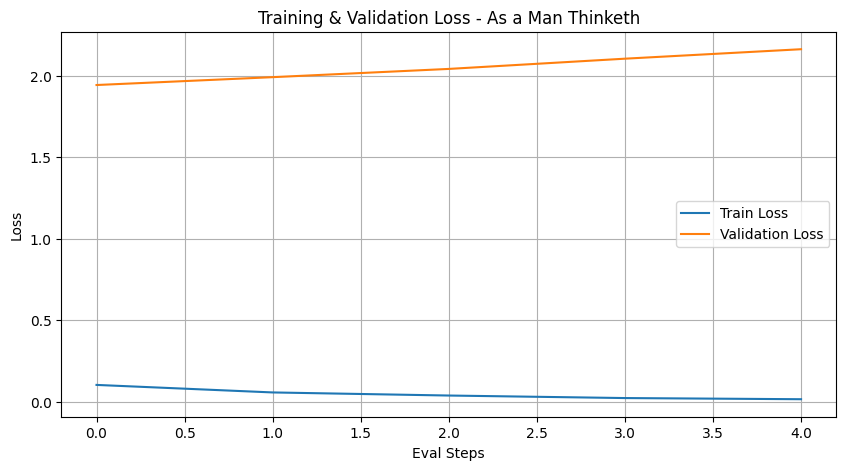


=== Final Output (temperature=0.5, top_k=50) ===
Good thoughts and actions can never produce. The man who does not material possessions, is the measure of right thought; wretchedness, and the inner with the outer, of the man may be known to himself) cannot be judged by another from the external aspect of his life.



In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

# train/val split
split      = int(0.9 * len(raw_text))
train_text = raw_text[:split]
val_text   = raw_text[split:]

train_loader = create_dataloader(
    train_text, tokenizer,
    batch_size=4, max_length=256, stride=128, shuffle=True
)
val_loader = create_dataloader(
    val_text, tokenizer,
    batch_size=4, max_length=256, stride=128, shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

optimizer = torch.optim.AdamW(
    model.parameters(), lr=3e-4, weight_decay=0.1
)

start_context = "Good thoughts and actions can never"

train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=30,
    eval_freq=50,
    eval_iter=5,
    tokenizer=tokenizer,
    start_context=start_context,
    temperature=0.8, 
    top_k=50
)

plot_losses(train_losses, val_losses)

print("\n=== Final Output (temperature=0.5, top_k=50) ===")
generate_and_print(
    model, tokenizer, start_context, device,
    max_new_tokens=50, temperature=0.8, top_k=50
)

The training loss converges near 0 while validation loss rises to ~2.2, indicating the model has overfit the training data. This is expected given the extremely small dataset size of only 4,706 tokens (~9 training batches), which is insufficient for a 6-layer, 256-dim GPT-style transformer to generalize.